# Spice

In [1]:
from spacerocks.spice import SpiceKernel
from spacerocks import SpaceRock
from spacerocks.time import Time

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Manually instantiate a SpiceKernel object, and load relevant spice kernels located on your local machine 
# NOTE: The kernel will crash if you try to load a kernel from a path that does not exist on your local machine
kernel = SpiceKernel()
kernel.load("/Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls")
kernel.load("/Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc")


Loading kernel: /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls
Loading kernel: /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc


In [3]:
# See the list of loaded kernels
kernel.loaded_kernels


['/Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls',
 '/Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc']

In [4]:
# Alternatively, you can use the defaults method to load the default kernels needed for most (all?) relevant Spacerocks functionality
# It will default to checking for spice files in a directory located at ~/.spacerocks/spice, and will make that directory if it doesn't exist.
# If you already have a file there, it will use that instead of the downloading again.
# Default is to download missing kernels, but you can set download=False to only load kernels that are already present. 
# You will get a ValueError if you try to load a kernel that is not present.

# NOTE: The earth.bpc file is re-downloaded every time you run thi as it is updated much more frequently than the other kernels.
kernel_default = SpiceKernel.defaults()


Using default configuration:
  Kernel paths: ["/Users/thomasruch/.spacerocks/spice"]
  Download directory: "/Users/thomasruch/.spacerocks/spice"
  Auto-download: true

Processing kernel: latest_leapseconds.tls
✓ Found existing kernel at: /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls
Loading kernel: /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls

Processing kernel: de440s.bsp
✓ Found existing kernel at: /Users/thomasruch/.spacerocks/spice/de440s.bsp
Loading kernel: /Users/thomasruch/.spacerocks/spice/de440s.bsp

Processing kernel: earth_1962_240827_2124_combined.bpc
➜ Downloading kernel...
    Saving to /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc
Loading kernel: /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc

Processing kernel: codes_300ast_20100725.bsp
✓ Found existing kernel at: /Users/thomasruch/.spacerocks/spice/codes_300ast_20100725.bsp
Loading kernel: /Users/thomasruch/.spacerocks/spice/codes_300ast_201

In [5]:
# You can also use the force_download=True flag to force the download of all kernels, even if they are already present, for both
# the defaults method and the from_config method.
kernel_default = SpiceKernel.defaults(force_download=True)


Using default configuration:
  Kernel paths: ["/Users/thomasruch/.spacerocks/spice"]
  Download directory: "/Users/thomasruch/.spacerocks/spice"
  Auto-download: true

Processing kernel: latest_leapseconds.tls
➜ Downloading kernel...
    Saving to /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls
Loading kernel: /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls

Processing kernel: de440s.bsp
➜ Downloading kernel...
    Saving to /Users/thomasruch/.spacerocks/spice/de440s.bsp
Loading kernel: /Users/thomasruch/.spacerocks/spice/de440s.bsp

Processing kernel: earth_1962_240827_2124_combined.bpc
➜ Downloading kernel...
    Saving to /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc
Loading kernel: /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc

Processing kernel: codes_300ast_20100725.bsp
➜ Downloading kernel...
    Saving to /Users/thomasruch/.spacerocks/spice/codes_300ast_20100725.bsp
Loading kernel: /Users/thomasruch/.spa

In [6]:
kernel_default

SpiceKernel:
  - /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls
  - /Users/thomasruch/.spacerocks/spice/de440s.bsp
  - /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc
  - /Users/thomasruch/.spacerocks/spice/codes_300ast_20100725.bsp
  - /Users/thomasruch/.spacerocks/spice/codes_300ast_20100725.tf

In [7]:
# Alternatively, use configuration file to download + load kernels


# Included is a config file has default kernels needed for running most relevant operation in SpaceRocks, an auto_download flag, a path to check for kernels and a path to download kernels to.
# If you have spice files saved somewhere else, add this path to the config file.
# If download_dir is not specified in the config, it saves to ~/.spacerocks/spice
kernel_from_config = SpiceKernel.from_config("/Users/thomasruch/srnew1/spacerocks/config.toml")

Loading configuration from /Users/thomasruch/srnew1/spacerocks/config.toml

Configuration loaded:
  Kernel paths: ["/Users/thomasruch/Gerdes", "/Users/thomasruch/.spacerocks/spice/"]
  Download directory: "/Users/thomasruch/.spacerocks/spice"
  Auto-download: true

Processing kernel: latest_leapseconds.tls
✓ Found existing kernel at: /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls
Loading kernel: /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls

Processing kernel: de440s.bsp
✓ Found existing kernel at: /Users/thomasruch/.spacerocks/spice/de440s.bsp
Loading kernel: /Users/thomasruch/.spacerocks/spice/de440s.bsp

Processing kernel: earth_1962_240827_2124_combined.bpc
➜ Downloading kernel...
    Saving to /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc
Loading kernel: /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc

Processing kernel: codes_300ast_20100725.bsp
✓ Found existing kernel at: /Users/thomasruch/.spacerocks/spi

In [8]:
kernel_from_config

SpiceKernel:
  - /Users/thomasruch/.spacerocks/spice/latest_leapseconds.tls
  - /Users/thomasruch/.spacerocks/spice/de440s.bsp
  - /Users/thomasruch/.spacerocks/spice/earth_1962_240827_2124_combined.bpc
  - /Users/thomasruch/.spacerocks/spice/codes_300ast_20100725.bsp
  - /Users/thomasruch/.spacerocks/spice/codes_300ast_20100725.tf

In [9]:
t0 = Time.now()

In [10]:
planets_names = ["mercury barycenter", 
                 "venus barycenter", 
                 "earth", 
                 "mars barycenter", 
                 "jupiter barycenter", 
                 "saturn barycenter", 
                 "uranus barycenter", 
                 "neptune barycenter"]

In [11]:
planets = {name: SpaceRock.from_spice(name, t0, origin = "SSB") for name in planets_names}
planet_positions = {planet: [] for planet in planets}

In [12]:
# Propagate the planets for 300 years

epochs = np.linspace(t0.epoch, t0.epoch + 365.25 * 300, 10_000)
counter = 0
for epoch in epochs:

    t = Time(epoch, timescale='utc', format='jd')

    for name, planet in planets.items():
        planet.analytic_propagate(t)
        x, y, z = planet.position
        planet_positions[name].append([x, y, z])

Text(0, 0.5, 'y (au)')

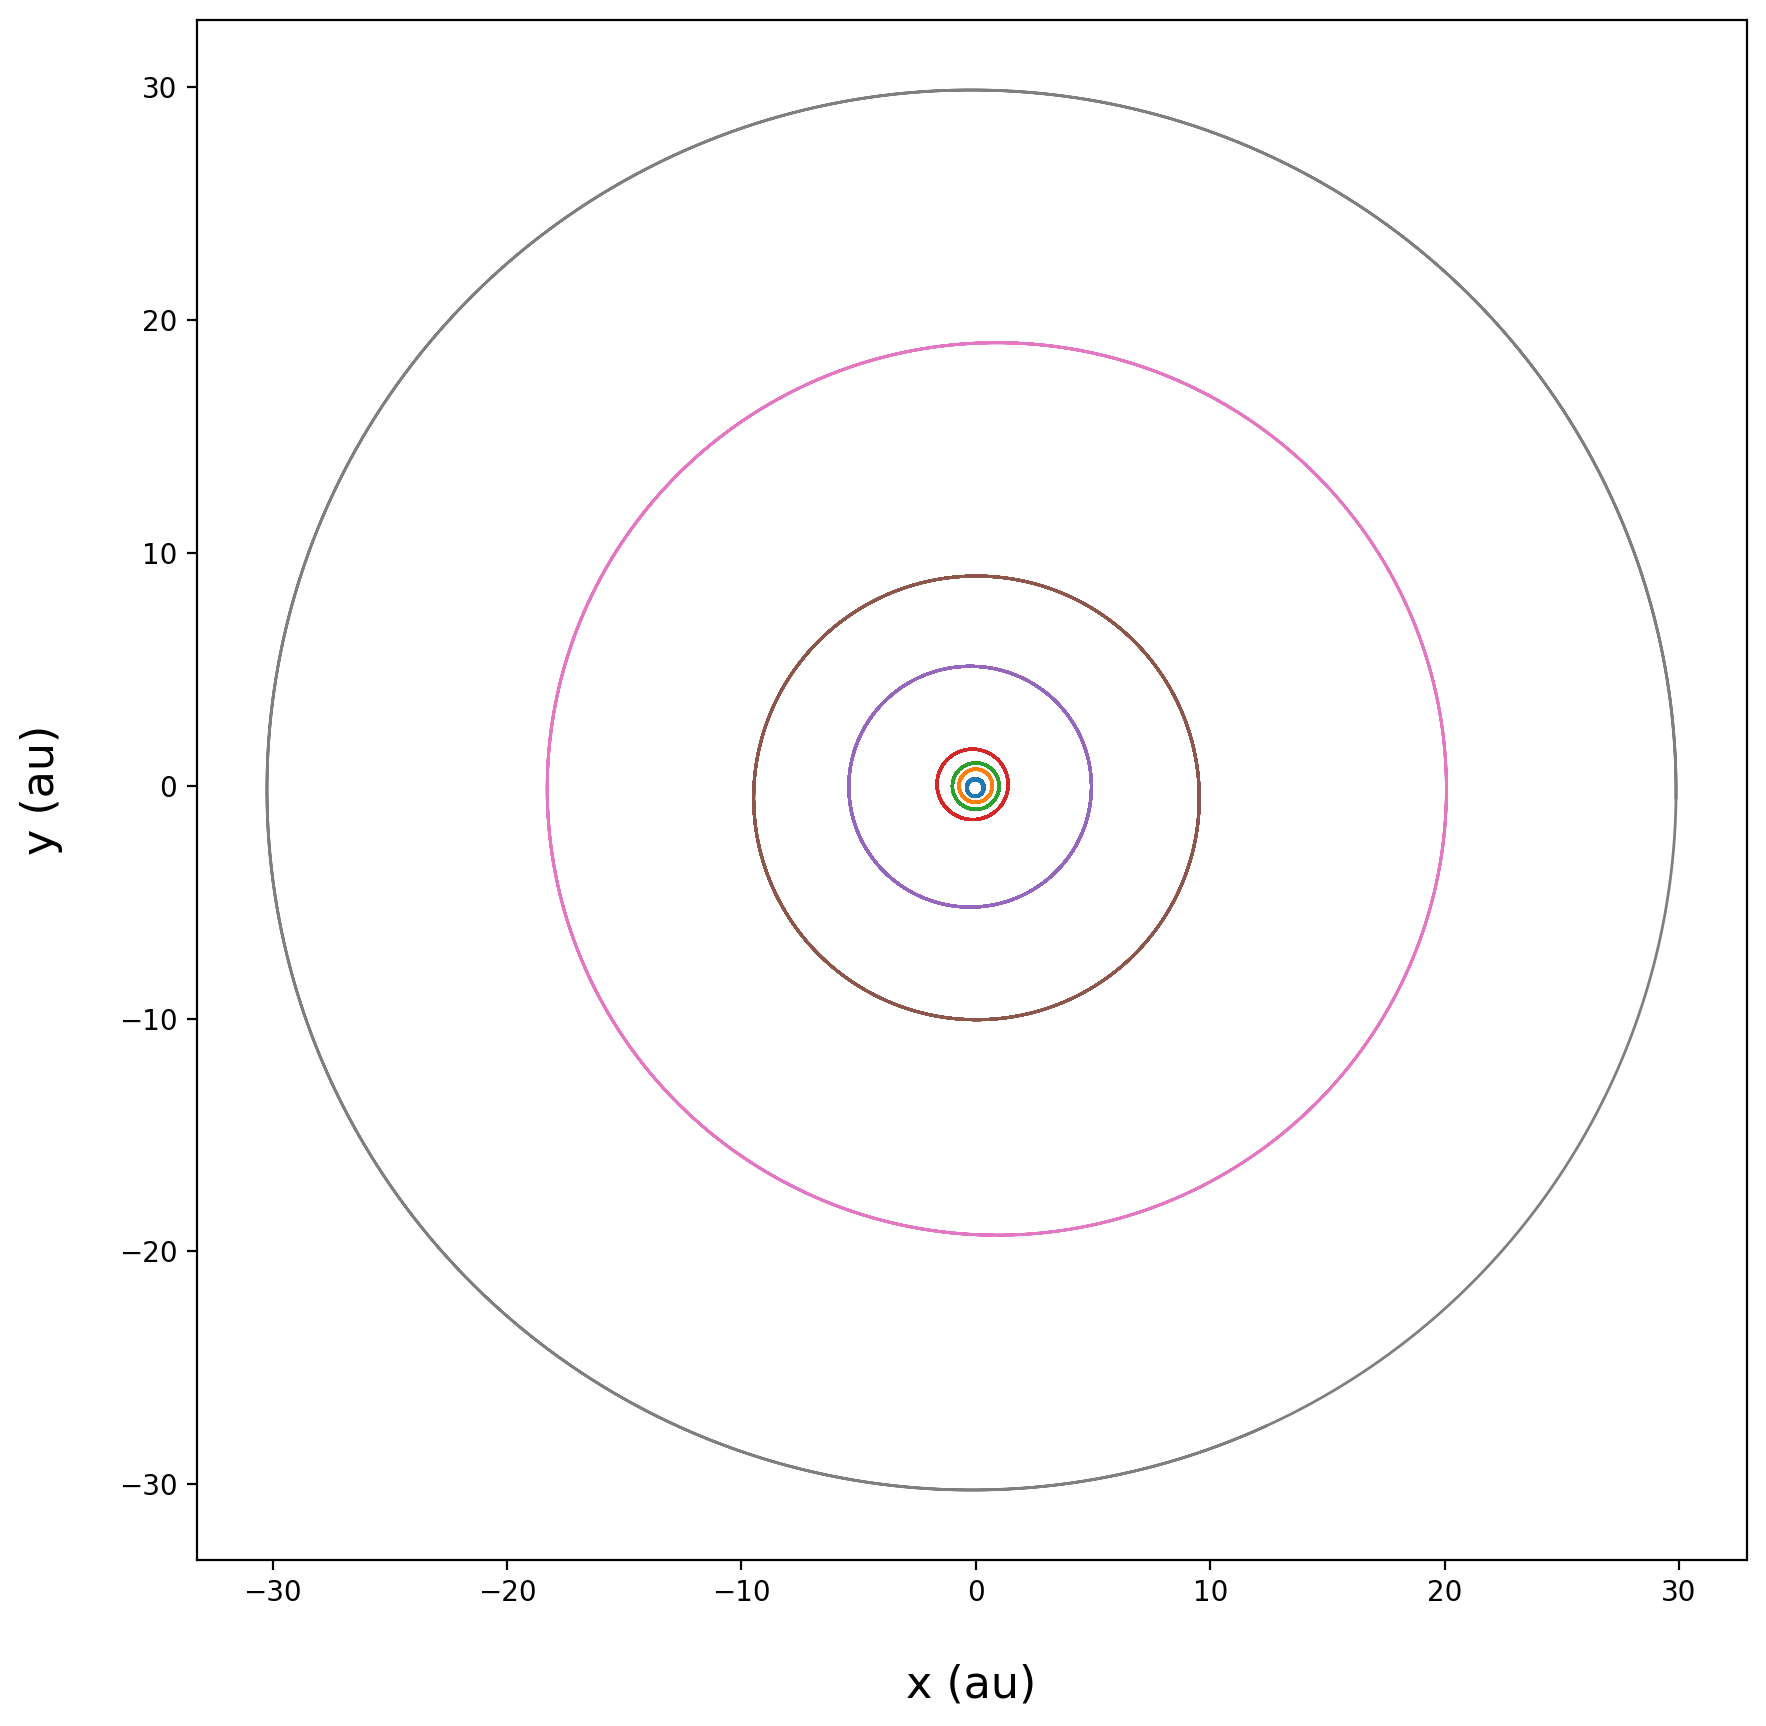

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

for name, positions in planet_positions.items():
    x, y, z = np.array(positions).T
    ax.plot(x, y, label=name, lw=1)

ax.set_xlabel("x (au)", fontsize=16, labelpad=20)
ax.set_ylabel("y (au)", fontsize=16, labelpad=20)